In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [108]:
#data loading
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
print(df.head(5))

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [109]:
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [110]:
# 4. DATA CLEANING

In [111]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [112]:
df.duplicated().sum()
df = df.drop_duplicates()#remove duplicates

In [113]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [114]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_name'] = df['Order Date'].dt.strftime('%b')

In [115]:
#vectorization better than apply
# Profit category
df['Profit_Category'] = np.where(df['Profit'] > 0, 'Profit', 'Loss')

In [116]:
#EDA

In [117]:
#top category by sales
Category_Sales =df.groupby(['Category','Region'])['Sales'].sum().reset_index()
print(Category_Sales)

           Category   Region        Sales
0         Furniture  Central  163797.1638
1         Furniture     East  208291.2040
2         Furniture    South  117298.6840
3         Furniture     West  252612.7435
4   Office Supplies  Central  167026.4150
5   Office Supplies     East  205516.0550
6   Office Supplies    South  125651.3130
7   Office Supplies     West  220853.2490
8        Technology  Central  170416.3120
9        Technology     East  264973.9810
10       Technology    South  148771.9080
11       Technology     West  251991.8320


In [118]:
# top categories by profit
Category_Profit = df.groupby(['Category','Region'])['Profit'].sum().reset_index()
print(Category_Profit)

           Category   Region      Profit
0         Furniture  Central  -2871.0494
1         Furniture     East   3046.1658
2         Furniture    South   6771.2061
3         Furniture     West  11504.9503
4   Office Supplies  Central   8879.9799
5   Office Supplies     East  41014.5791
6   Office Supplies    South  19986.3928
7   Office Supplies     West  52609.8490
8        Technology  Central  33697.4320
9        Technology     East  47462.0351
10       Technology    South  19991.8314
11       Technology     West  44303.6496


In [119]:
#monthly sales trend
monthly_sales = df.groupby(['Year','Month','Month_name','Order Date','Category','Region'])['Sales'].sum().reset_index().sort_values(['Year','Month'])
print(monthly_sales)

      Year  Month Month_name Order Date         Category   Region     Sales
0     2014      1        Jan 2014-01-03  Office Supplies  Central    16.448
1     2014      1        Jan 2014-01-04  Office Supplies  Central   288.060
2     2014      1        Jan 2014-01-05  Office Supplies     East    19.536
3     2014      1        Jan 2014-01-06        Furniture    South  2573.820
4     2014      1        Jan 2014-01-06  Office Supplies    South   665.900
...    ...    ...        ...        ...              ...      ...       ...
5171  2017     12        Dec 2017-12-30        Furniture     East   323.136
5172  2017     12        Dec 2017-12-30  Office Supplies  Central   209.300
5173  2017     12        Dec 2017-12-30  Office Supplies     East    52.776
5174  2017     12        Dec 2017-12-30  Office Supplies     West    37.648
5175  2017     12        Dec 2017-12-30       Technology     East    90.930

[5176 rows x 7 columns]


In [120]:
#region-wise sales
sales_by_region=df.groupby(['Region','Category'])['Sales'].sum().reset_index()
print(sales_by_region)

     Region         Category        Sales
0   Central        Furniture  163797.1638
1   Central  Office Supplies  167026.4150
2   Central       Technology  170416.3120
3      East        Furniture  208291.2040
4      East  Office Supplies  205516.0550
5      East       Technology  264973.9810
6     South        Furniture  117298.6840
7     South  Office Supplies  125651.3130
8     South       Technology  148771.9080
9      West        Furniture  252612.7435
10     West  Office Supplies  220853.2490
11     West       Technology  251991.8320


In [121]:
#Top 10 Customers
top_customers = df.groupby(['Customer Name','Category','Region'])['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False).head(10)
print(top_customers)

           Customer Name         Category   Region      Sales
4132         Sean Miller       Technology    South  23459.780
4397        Tamara Chand       Technology  Central  17499.950
3743        Raymond Buch       Technology     West  14110.336
4554        Tom Ashbrook       Technology     East  13652.558
44         Adrian Barton  Office Supplies  Central  11318.532
1997        Hunter Lopez       Technology     East  10499.970
4025        Sanjit Chand  Office Supplies  Central   9900.190
534         Bill Shonely       Technology     East   9099.930
4037        Sanjit Engle       Technology    South   8749.950
917   Christopher Conant       Technology     East   8522.358


In [122]:
#total orders
orders = df.groupby(['Customer Name','Region','Category'])['Order ID'].count().reset_index()
print(orders)

           Customer Name   Region         Category  Order ID
0          Aaron Bergman  Central        Furniture         1
1          Aaron Bergman  Central  Office Supplies         1
2          Aaron Bergman  Central       Technology         1
3          Aaron Bergman     West        Furniture         1
4          Aaron Bergman     West  Office Supplies         2
...                  ...      ...              ...       ...
4763  Zuschuss Donatelli    South        Furniture         1
4764  Zuschuss Donatelli    South  Office Supplies         1
4765  Zuschuss Donatelli    South       Technology         1
4766  Zuschuss Donatelli     West  Office Supplies         3
4767  Zuschuss Donatelli     West       Technology         1

[4768 rows x 4 columns]


In [123]:
#top 10 most profitable products
best_products =df.groupby('Product Name')['Profit'].sum().reset_index().sort_values(by='Profit',ascending=False).head(10)
print(best_products)

                                           Product Name      Profit
404               Canon imageCLASS 2200 Advanced Copier  25199.9280
650   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805                Hewlett Packard LaserJet 3310 Copier   6983.8836
400                  Canon PC1060 Personal Laser Copier   4570.9347
787   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
165                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
19     3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
1276  Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
895                Ibico EPK-21 Electric Binding System   3345.2823
1840                  Zebra ZM400 Thermal Label Printer   3343.5360


In [124]:
#Least Profitable Products
low_profitable_products = df[df['Profit'] < 0].groupby('Product Name')['Profit'].sum().reset_index().sort_values(by='Profit').head(10)

In [125]:
#sales vs profit 
sales_profit = df.groupby(['Category','Region'])[['Sales','Profit']].sum().reset_index()

In [126]:
#ranking customer by sales
df['Customer_Rank'] = df.groupby('Customer Name')['Sales'].transform('sum').rank(ascending=False)

In [127]:
#repeated customers
df['Customer Name'].value_counts().head(10)

Customer Name
William Brown          37
John Lee               34
Paul Prost             34
Matt Abelman           34
Seth Vernon            32
Edward Hooks           32
Jonathan Doherty       32
Chloris Kastensmidt    32
Arthur Prichep         31
Zuschuss Carroll       31
Name: count, dtype: int64

In [128]:
#average order value
avg_order_value = df['Sales'].mean()

In [129]:
#correlation
correlation = df[['Sales','Profit','Quantity']].corr()

In [130]:
#visualization

In [131]:
sns.set(style="whitegrid")

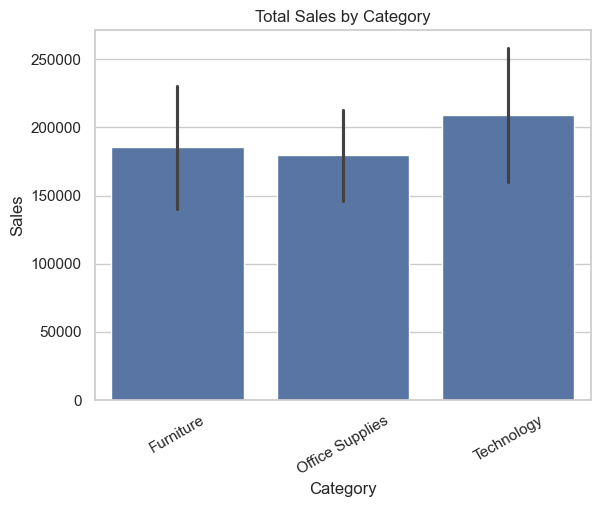

In [132]:
#sales by category
plt.figure()
sns.barplot(x='Category', y='Sales', data=Category_Sales)
plt.title("Total Sales by Category")
plt.xticks(rotation=30)
plt.show()


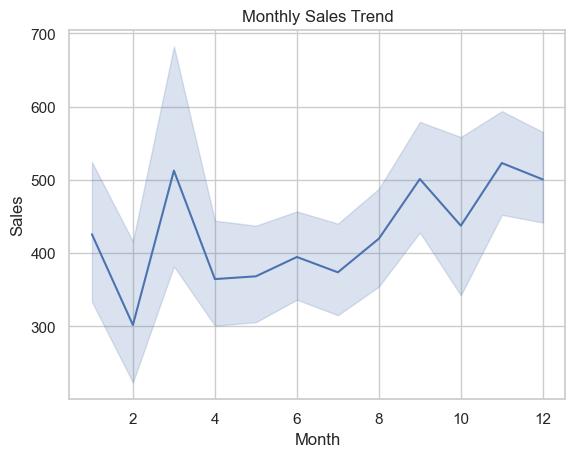

In [133]:
plt.figure()
sns.lineplot(x='Month', y='Sales', data=monthly_sales)
plt.title("Monthly Sales Trend")
plt.show()

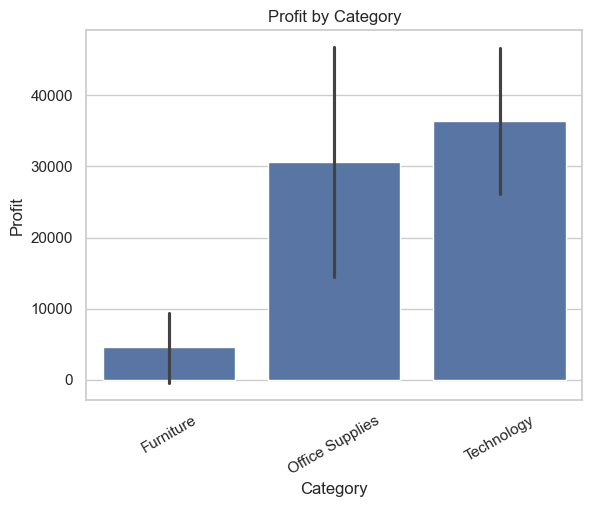

In [134]:
plt.figure()
sns.barplot(x='Category', y='Profit', data=Category_Profit)
plt.title("Profit by Category")
plt.xticks(rotation=30)
plt.show()

In [135]:
#exporting data for power bi

In [136]:
export_path = r"E:\pandas_Dashboard\\"

In [137]:
# 1. Monthly Sales
monthly_sales.to_csv(export_path + "monthly_sales.csv", index=False)

# 2. Category Sales
Category_Sales.to_csv(export_path + "category_sales.csv", index=False)

# 3. Category Profit
Category_Profit.to_csv(export_path + "category_profit.csv", index=False)

# 4. Top Customers
top_customers.to_csv(export_path + "top_customers.csv", index=False)

# 5. Region Sales
sales_by_region.to_csv(export_path + "region_sales.csv", index=False)

# 6. Sales vs Profit
sales_profit.to_csv(export_path + "sales_profit.csv", index=False)
#7 Total orders
orders.to_csv(export_path+'total_orders.csv',index=False)

print("All files exported successfully to E:\\pandas_Dashboard")

All files exported successfully to E:\pandas_Dashboard
